## Exploring SpatialData

In [1]:
# Import Xenium dataset

from spatialdata_io import xenium

sdata = xenium(
    "../data/raw/breast-cancer-10x-xenium-bundle"
)

print(sdata)

SpatialData object
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
│     └── 'nucleus_labels': DataTree[yx] (25778, 35416), (12889, 17708), (6444, 8854), (3222, 4427), (1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts 

In [2]:
# Inspect keys in the dataset
print(sdata.images.keys())
print(sdata.shapes.keys())
print(sdata.tables.keys())

dict_keys(['morphology_mip', 'morphology_focus'])
dict_keys(['nucleus_boundaries', 'cell_boundaries'])
dict_keys(['table'])


Xenium SpatialData object has 5 elements: (1) Images, (2) Labels, (3) Points, (4) Shapes, (5) Tables. 

`Images`: microscopy images in '.ome.tif' format (.tif images with additional metadata) --> Raster geometry (c - channel, y - height, x - width).    
`Labels`: cell and nucleus segmentation masks at pixel-level --> Raster geometry (c - channel, y - height, x - width).   
`Points`: transcript locations as coordinates (in micrometer) --> Vector geometry (3D coordinates and features).    
`Shapes`: ROI (2D shapes like polygons, circles, etc)  --> Vector geometry (Cell ID vs geometry).    
`Tables`: Single cell expression matrix (Anndata) --> Annotations for other elements (except images). 

In [3]:
sdata.points["transcripts"].head()

,x,y,z,feature_name,cell_id,transcript_id,overlaps_nucleus,qv
0,4.395842,328.666473,12.019493,SEC11C,565,281474976710656,0,18.662479
1,5.074415,236.964844,7.608510,NegControlCodeword_0502,540,281474976710657,0,18.634956
2,4.702023,322.797150,12.289083,SEC11C,562,281474976710658,0,18.662479
3,4.906601,581.428650,11.222615,DAPK3,271,281474976710659,0,20.821745
4,5.660699,720.851746,9.265523,TCIM,291,281474976710660,0,18.017488


In [4]:
sdata.shapes['cell_boundaries'].head()

,geometry
1,"POLYGON ((849.787 322.362, 844.263 323.212, 84..."
2,"POLYGON ((817.062 321.087, 816 329.375, 819.61..."
3,"POLYGON ((849.787 329.163, 847.875 330.438, 84..."
4,"POLYGON ((823.225 330.862, 821.525 331.5, 819...."
5,"POLYGON ((840.65 324.7, 835.763 326.612, 836.8..."


## Cropping Xenium dataset

In [11]:
# Crop the dataset
from data_processing.image_crop_function import image_crop

start = 11500
end = 2500

cropped_sdata, crop_xmin, crop_ymin = image_crop(
    sdata,
    start,
    start,
    start + end,
    start + end + 500,
    "global",
)

print(cropped_sdata)
print(crop_xmin, crop_ymin)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 3000, 2500), (1, 1500, 1250), (1, 750, 625), (1, 375, 313), (1, 187, 156)
│     └── 'morphology_mip': DataTree[cyx] (1, 3000, 2500), (1, 1500, 1250), (1, 750, 625), (1, 375, 313), (1, 187, 156)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3000, 2500), (1500, 1250), (750, 625), (375, 313), (187, 156)
│     └── 'nucleus_labels': DataTree[yx] (3000, 2500), (1500, 1250), (750, 625), (375, 313), (187, 156)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1721, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1721, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (1721, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_bo

`Tables` shows an Anndata object of roughly 1% cells i.e 1721 cells in the cropped dataset out of 167780 cells in the complete dataset

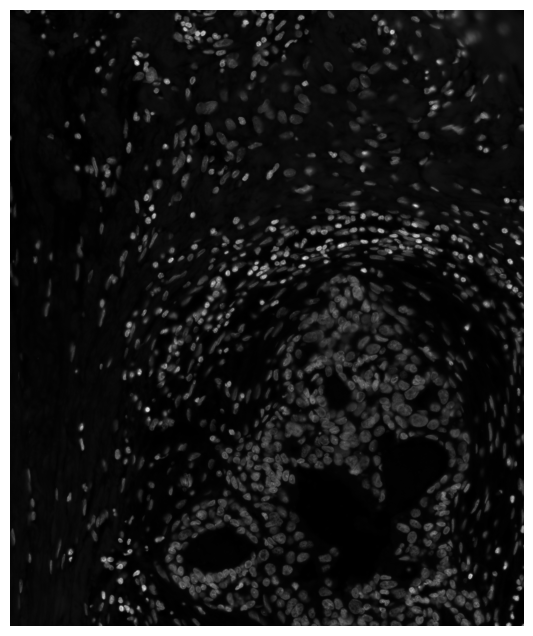

In [12]:
# Visualize cropped dataset
import matplotlib.pyplot as plt

img_np = (
    cropped_sdata.images["morphology_focus"]["scale0"]["image"]
    .compute()
)

plt.figure(figsize=(8,8))
plt.imshow(img_np.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

In [13]:
# Save cropped dataset as .ome.tif (so that its scportrait compatible)
import tifffile

img_np = (
    cropped_sdata.images["morphology_focus"]["scale0"]["image"]
    .compute()
)

tifffile.imwrite(
    "../data/processed/breast_cancer_rep1_roi_cropped_morphology_focus.ome.tif",
    img_np.squeeze().astype("uint16"),
    ome=True
)